# Entrenamiento local YOLOv11 — detección de persona

Este notebook está adaptado para trabajar en tu máquina local con la ruta:

```text
D:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\REENTRENAMIENTO_YOLO\person
```

Debe hacer el mismo flujo que `Entrenamiento_vehiculos_YOLOv11.ipynb`:

1. Preparar el dataset.
2. Crear `data.yaml`.
3. Entrenar YOLOv11.
4. Mostrar métricas.
5. Cargar `best.pt`.
6. Generar predicciones.


## 1. Configuración local

Coloca en esta carpeta:

```text
D:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\REENTRENAMIENTO_YOLO\person
```

estos archivos:

```text
Detector_YOLO.v1i.yolov11.zip
yolo11n.pt
```

Si tu modelo se llama `yolo11n(3).pt`, también será detectado automáticamente.


In [15]:
from pathlib import Path
import os
import sys
import shutil
import zipfile
import subprocess
import importlib.util

# ============================================================
# RUTA LOCAL DEL PROYECTO PERSON
# ============================================================
BASE_DIR = Path(r"D:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\REENTRENAMIENTO_YOLO\person")

# Si corres el notebook desde otra carpeta o en otra máquina,
# esta protección evita que falle inmediatamente.
if not BASE_DIR.exists():
    print("ADVERTENCIA: BASE_DIR no existe en esta máquina.")
    print("Se usará la carpeta actual del notebook:", Path.cwd())
    BASE_DIR = Path.cwd()

BASE_DIR = BASE_DIR.resolve()

# ============================================================
# PARÁMETROS PRINCIPALES
# ============================================================
DATASETS_DIR = BASE_DIR / "datasets"
DATASET_DIR = DATASETS_DIR / "dataset_person"
YAML_PATH = DATASET_DIR / "data.yaml"

RUNS_DIR = BASE_DIR / "runs"
EXPERIMENT_NAME = "person_yolo11n"

EPOCHS = 10
IMG_SIZE = 640
BATCH_SIZE = 8

# Umbral usado SOLO para predicción/visualización.
# Si sale "(no detections)", baja a 0.05 o 0.01 para diagnóstico.
CONF_THRES = 0.05
IOU_THRES = 0.45

# Si cambias el ZIP y quieres volver a extraer desde cero, déjalo en True.
EXTRACT_DATASET_AGAIN = True

# Nombre de clase usado en el dataset.
# El YAML original de Roboflow trae: names: ['cesar'].
# Si quieres que en las predicciones aparezca "person", cambia "cesar" por "person".
CLASS_NAMES = {
    0: "cesar"
}

print("BASE_DIR:", BASE_DIR)
print("DATASET_DIR:", DATASET_DIR)
print("RUNS_DIR:", RUNS_DIR)
print("EXPERIMENT_NAME:", EXPERIMENT_NAME)


BASE_DIR: D:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\REENTRENAMIENTO_YOLO\person
DATASET_DIR: D:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\REENTRENAMIENTO_YOLO\person\datasets\dataset_person
RUNS_DIR: D:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\REENTRENAMIENTO_YOLO\person\runs
EXPERIMENT_NAME: person_yolo11n


In [16]:
# ============================================================
# BÚSQUEDA ROBUSTA DE ARCHIVOS LOCALES
# ============================================================
def buscar_archivo(nombre_logico: str, nombres_exactos, patrones_glob) -> Path:
    """
    Busca archivos primero por nombres exactos y luego por patrones glob.
    Revisa BASE_DIR, la carpeta actual del notebook y el padre de BASE_DIR.
    """
    carpetas_busqueda = []
    for carpeta in [BASE_DIR, Path.cwd().resolve(), BASE_DIR.parent]:
        if carpeta not in carpetas_busqueda and carpeta.exists():
            carpetas_busqueda.append(carpeta)

    for carpeta in carpetas_busqueda:
        for nombre in nombres_exactos:
            candidato = carpeta / nombre
            if candidato.exists():
                print(f"{nombre_logico} encontrado:", candidato)
                return candidato

    for carpeta in carpetas_busqueda:
        for patron in patrones_glob:
            candidatos = sorted(carpeta.glob(patron))
            if candidatos:
                print(f"{nombre_logico} encontrado:", candidatos[0])
                return candidatos[0]

    raise FileNotFoundError(
        f"No se encontró {nombre_logico}.\n"
        f"Coloca el archivo en:\n{BASE_DIR}\n\n"
        f"Nombres buscados: {nombres_exactos}\n"
        f"Patrones buscados: {patrones_glob}"
    )


DATASET_ZIP = buscar_archivo(
    "dataset ZIP",
    nombres_exactos=[
        "Detector_YOLO.v1i.yolov11.zip",
        "Detector_YOLO.zip",
        "dataset_person.zip",
        "person.zip"
    ],
    patrones_glob=[
        "Detector_YOLO*.zip",
        "*person*.zip",
        "*.zip"
    ]
)

MODEL_PATH = buscar_archivo(
    "modelo base YOLO",
    nombres_exactos=[
        "yolo11n.pt",
        "yolo11n(3).pt",
        "yolo11s.pt",
    ],
    patrones_glob=[
        "yolo11*.pt",
        "*.pt"
    ]
)

print("\nDataset ZIP:", DATASET_ZIP)
print("Modelo base:", MODEL_PATH)


dataset ZIP encontrado: D:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\REENTRENAMIENTO_YOLO\person\Detector_YOLO.v1i.yolov11.zip
modelo base YOLO encontrado: D:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\REENTRENAMIENTO_YOLO\person\yolo11n.pt

Dataset ZIP: D:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\REENTRENAMIENTO_YOLO\person\Detector_YOLO.v1i.yolov11.zip
Modelo base: D:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\REENTRENAMIENTO_YOLO\person\yolo11n.pt


## 2. Preparación del dataset

El dataset `Detector_YOLO.v1i.yolov11.zip` viene en formato Roboflow YOLOv11 con esta estructura:

```text
train/images
train/labels
valid/images
valid/labels
data.yaml
```

Este ZIP no trae carpeta `test`. Por eso, para predicciones finales el notebook usará `valid/images` como conjunto de prueba si no existe `test/images`.


In [17]:
# ============================================================
# EXTRACCIÓN SEGURA DEL DATASET
# ============================================================
def extraer_zip_seguro(zip_path: Path, destino: Path):
    """
    Extrae un ZIP evitando rutas maliciosas como ../../archivo.
    """
    destino = destino.resolve()
    with zipfile.ZipFile(zip_path, "r") as zf:
        for member in zf.infolist():
            member_path = (destino / member.filename).resolve()
            if not str(member_path).startswith(str(destino)):
                raise RuntimeError(f"Ruta insegura dentro del ZIP: {member.filename}")
        zf.extractall(destino)


DATASETS_DIR.mkdir(parents=True, exist_ok=True)

if DATASET_DIR.exists() and EXTRACT_DATASET_AGAIN:
    print("Eliminando dataset anterior:", DATASET_DIR)
    shutil.rmtree(DATASET_DIR)

if not DATASET_DIR.exists():
    DATASET_DIR.mkdir(parents=True, exist_ok=True)
    print("Extrayendo dataset...")
    extraer_zip_seguro(DATASET_ZIP, DATASET_DIR)
else:
    print("Dataset ya existe. No se volvió a extraer:", DATASET_DIR)

print("Dataset preparado en:", DATASET_DIR)

print("\nContenido principal:")
for p in sorted(DATASET_DIR.iterdir()):
    print(" -", p.name)


Eliminando dataset anterior: D:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\REENTRENAMIENTO_YOLO\person\datasets\dataset_person
Extrayendo dataset...
Dataset preparado en: D:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\REENTRENAMIENTO_YOLO\person\datasets\dataset_person

Contenido principal:
 - data.yaml
 - README.dataset.txt
 - README.roboflow.txt
 - train
 - valid


In [19]:
# ============================================================
# DETECCIÓN DE SPLITS
# ============================================================
def existe_split(split: str) -> bool:
    return (DATASET_DIR / split / "images").exists() and (DATASET_DIR / split / "labels").exists()

TRAIN_SPLIT = "train"

if existe_split("valid"):
    VAL_SPLIT = "valid"
elif existe_split("val"):
    VAL_SPLIT = "val"
else:
    raise FileNotFoundError(
        "No se encontró carpeta de validación. Se esperaba valid/images o val/images."
    )

if existe_split("test"):
    TEST_SPLIT = "test"
else:
    TEST_SPLIT = VAL_SPLIT
    print("ADVERTENCIA: no existe test/images. Se usará valid/images para predicción final.")

print("TRAIN_SPLIT:", TRAIN_SPLIT)
print("VAL_SPLIT  :", VAL_SPLIT)
print("TEST_SPLIT :", TEST_SPLIT)


ADVERTENCIA: no existe test/images. Se usará valid/images para predicción final.
TRAIN_SPLIT: train
VAL_SPLIT  : valid
TEST_SPLIT : valid


In [21]:
# ============================================================
# CREACIÓN DE data.yaml COMPATIBLE CON YOLO
# ============================================================
def escribir_data_yaml():
    names_yaml = "\n".join([f"  {idx}: {name}" for idx, name in CLASS_NAMES.items()])

    yaml_text = (
        f"path: {DATASET_DIR.resolve().as_posix()}\n"
        f"train: {TRAIN_SPLIT}/images\n"
        f"val: {VAL_SPLIT}/images\n"
        f"test: {TEST_SPLIT}/images\n\n"
        f"names:\n"
        f"{names_yaml}\n"
    )

    YAML_PATH.write_text(yaml_text, encoding="utf-8")


escribir_data_yaml()

print("Archivo data.yaml creado en:", YAML_PATH)
print("\nContenido de data.yaml:\n")
print(YAML_PATH.read_text(encoding="utf-8"))


Archivo data.yaml creado en: D:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\REENTRENAMIENTO_YOLO\person\datasets\dataset_person\data.yaml

Contenido de data.yaml:

path: D:/CICLO 2026-1 UNI/Project_IA/[2] CODIGO/REENTRENAMIENTO_YOLO/person/datasets/dataset_person
train: train/images
val: valid/images
test: valid/images

names:
  0: cesar



In [22]:
# ============================================================
# VALIDACIÓN DE IMÁGENES Y LABELS
# ============================================================
EXTENSIONES_IMAGEN = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def validar_split(split: str, obligatorio: bool = True):
    images_dir = DATASET_DIR / split / "images"
    labels_dir = DATASET_DIR / split / "labels"

    if not images_dir.exists() or not labels_dir.exists():
        if obligatorio:
            raise FileNotFoundError(f"Falta la estructura {split}/images o {split}/labels.")
        print(f"{split:5s} -> no existe")
        return 0, 0

    imagenes = sorted([p for p in images_dir.iterdir() if p.suffix.lower() in EXTENSIONES_IMAGEN])
    labels = sorted(labels_dir.glob("*.txt"))

    nombres_imagen = {p.stem for p in imagenes}
    nombres_label = {p.stem for p in labels}

    faltan_labels = nombres_imagen - nombres_label
    labels_sin_imagen = nombres_label - nombres_imagen

    print(f"{split:5s} -> imágenes: {len(imagenes):4d} | labels: {len(labels):4d}")

    if faltan_labels:
        print(f"  ADVERTENCIA: imágenes sin label: {len(faltan_labels)}")
        for x in sorted(list(faltan_labels))[:10]:
            print("   -", x)

    if labels_sin_imagen:
        print(f"  ADVERTENCIA: labels sin imagen: {len(labels_sin_imagen)}")
        for x in sorted(list(labels_sin_imagen))[:10]:
            print("   -", x)

    # Verificación básica del formato YOLO: class x_center y_center width height
    ids_clase = set()
    labels_vacios = 0

    for label_path in labels:
        contenido = label_path.read_text(encoding="utf-8").strip()
        if not contenido:
            labels_vacios += 1
            continue

        for linea in contenido.splitlines():
            partes = linea.split()
            if len(partes) != 5:
                raise ValueError(f"Label con formato incorrecto en {label_path}: {linea}")

            cls = int(float(partes[0]))
            valores = [float(v) for v in partes[1:]]

            if cls not in CLASS_NAMES:
                raise ValueError(
                    f"Clase {cls} encontrada en {label_path}, pero no está en CLASS_NAMES."
                )

            if not all(0.0 <= v <= 1.0 for v in valores):
                raise ValueError(
                    f"Coordenadas fuera de [0,1] en {label_path}: {linea}"
                )

            ids_clase.add(cls)

    if labels_vacios:
        print(f"  ADVERTENCIA: labels vacíos: {labels_vacios}")

    print(f"  clases encontradas: {sorted(ids_clase)}")

    return len(imagenes), len(labels)


validar_split(TRAIN_SPLIT, obligatorio=True)
validar_split(VAL_SPLIT, obligatorio=True)

if TEST_SPLIT not in {TRAIN_SPLIT, VAL_SPLIT}:
    validar_split(TEST_SPLIT, obligatorio=False)

print("\nValidación terminada.")


train -> imágenes:   70 | labels:   70
  clases encontradas: [0]
valid -> imágenes:   17 | labels:   17
  clases encontradas: [0]

Validación terminada.


## 3. Instalación / verificación de Ultralytics

Esta celda verifica si `ultralytics` ya está instalado. Si no está instalado, lo instala en el mismo entorno de Python donde estás ejecutando Jupyter.


In [23]:
# ============================================================
# INSTALACIÓN / VERIFICACIÓN DE ULTRALYTICS
# ============================================================
if importlib.util.find_spec("ultralytics") is None:
    print("Ultralytics no está instalado. Instalando...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "ultralytics"])
else:
    print("Ultralytics ya está instalado.")

from ultralytics import YOLO

print("Importación de YOLO correcta.")


Ultralytics ya está instalado.
Importación de YOLO correcta.


## 4. Entrenamiento YOLOv11

Parámetros usados:

```python
epochs = 10
imgsz = 640
batch = 8
workers = 0
```

`workers=0` es importante en Windows/Jupyter para evitar bloqueos del `DataLoader`.


In [24]:
from ultralytics import YOLO
import torch

# Usa GPU si está disponible. Si no, usa CPU.
DEVICE = 0 if torch.cuda.is_available() else "cpu"

print("Dispositivo de entrenamiento:", DEVICE)
print("Modelo base:", MODEL_PATH)
print("Dataset YAML:", YAML_PATH)
print("Carpeta de salida:", RUNS_DIR / EXPERIMENT_NAME)

model = YOLO(str(MODEL_PATH))

results = model.train(
    data=str(YAML_PATH),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    workers=0,
    project=str(RUNS_DIR),
    name=EXPERIMENT_NAME,
    exist_ok=True,
    plots=True
)

TRAIN_DIR = Path(results.save_dir)
BEST_MODEL_PATH = TRAIN_DIR / "weights" / "best.pt"
LAST_MODEL_PATH = TRAIN_DIR / "weights" / "last.pt"

print("\nEntrenamiento terminado.")
print("Carpeta real de entrenamiento:", TRAIN_DIR)
print("Mejor modelo :", BEST_MODEL_PATH)
print("Último modelo:", LAST_MODEL_PATH)

if not BEST_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"No se generó best.pt en {BEST_MODEL_PATH}. "
        "Revisa si el entrenamiento terminó correctamente."
    )


Dispositivo de entrenamiento: cpu
Modelo base: D:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\REENTRENAMIENTO_YOLO\person\yolo11n.pt
Dataset YAML: D:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\REENTRENAMIENTO_YOLO\person\datasets\dataset_person\data.yaml
Carpeta de salida: D:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\REENTRENAMIENTO_YOLO\person\runs\person_yolo11n
New https://pypi.org/project/ultralytics/8.4.82 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.62  Python-3.14.0 torch-2.12.0+cpu CPU (Intel Core i7-7700 3.60GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\REENTRENAMIENTO_YOLO\person\datasets\dataset_person\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=Fal

## 5. Métricas del entrenamiento

Primero se intenta mostrar `results.png`. Si Ultralytics no lo genera, se crea una gráfica manual usando `results.csv`.


Carpeta real usada para resultados: D:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\REENTRENAMIENTO_YOLO\person\runs\person_yolo11n
No existe results.png, pero sí existe results.csv.
Se generará una gráfica manual desde results.csv.


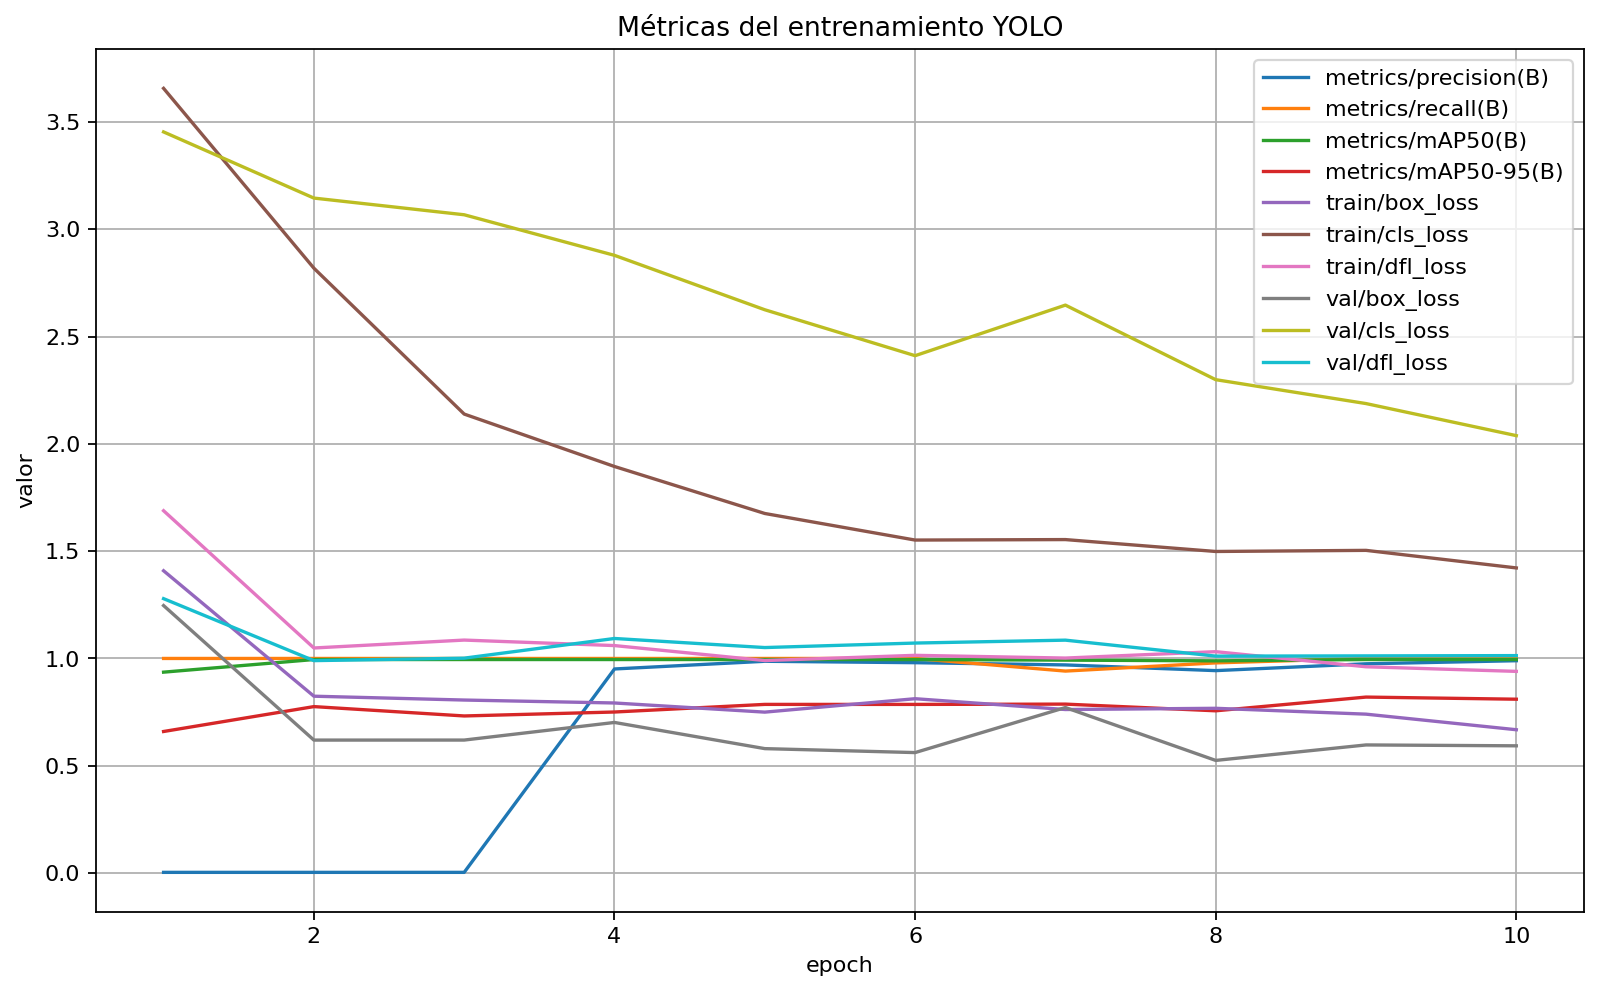

In [25]:
from IPython.display import Image as IPyImage, display
from pathlib import Path

def obtener_train_dir() -> Path:
    runs_dir = Path(RUNS_DIR)
    candidatos = []

    def registrar(carpeta: Path):
        carpeta = Path(carpeta)
        if not carpeta.exists() or not carpeta.is_dir():
            return

        results_png = carpeta / "results.png"
        results_csv = carpeta / "results.csv"
        best_pt = carpeta / "weights" / "best.pt"
        last_pt = carpeta / "weights" / "last.pt"

        archivos_validos = [p for p in [results_png, results_csv, best_pt, last_pt] if p.exists()]
        if not archivos_validos:
            return

        prioridad = 0
        if results_png.exists():
            prioridad += 100
        if results_csv.exists():
            prioridad += 50
        if best_pt.exists():
            prioridad += 20
        if last_pt.exists():
            prioridad += 10

        mtime = max(p.stat().st_mtime for p in archivos_validos)
        candidatos.append((prioridad, mtime, carpeta))

    if "TRAIN_DIR" in globals():
        registrar(Path(TRAIN_DIR))

    registrar(Path(RUNS_DIR) / EXPERIMENT_NAME)

    if runs_dir.exists():
        for p in runs_dir.rglob("results.png"):
            registrar(p.parent)
        for p in runs_dir.rglob("results.csv"):
            registrar(p.parent)
        for p in runs_dir.rglob("best.pt"):
            registrar(p.parent.parent)
        for p in runs_dir.rglob("last.pt"):
            registrar(p.parent.parent)

    if candidatos:
        candidatos = sorted(set(candidatos), key=lambda x: (x[0], x[1]), reverse=True)
        return candidatos[0][2]

    raise FileNotFoundError(
        "No se encontró una corrida válida. Ejecuta primero la celda de entrenamiento "
        "y verifica que termine sin errores."
    )


TRAIN_DIR = obtener_train_dir()
results_png = TRAIN_DIR / "results.png"
results_csv = TRAIN_DIR / "results.csv"

print("Carpeta real usada para resultados:", TRAIN_DIR)

if results_png.exists():
    display(IPyImage(filename=str(results_png), width=850))

elif results_csv.exists():
    print("No existe results.png, pero sí existe results.csv.")
    print("Se generará una gráfica manual desde results.csv.")

    import pandas as pd
    import matplotlib.pyplot as plt

    df = pd.read_csv(results_csv)
    df.columns = [c.strip() for c in df.columns]

    columnas_preferidas = [
        "metrics/precision(B)",
        "metrics/recall(B)",
        "metrics/mAP50(B)",
        "metrics/mAP50-95(B)",
        "train/box_loss",
        "train/cls_loss",
        "train/dfl_loss",
        "val/box_loss",
        "val/cls_loss",
        "val/dfl_loss",
    ]

    columnas = [c for c in columnas_preferidas if c in df.columns]

    if not columnas:
        raise FileNotFoundError(
            f"Se encontró results.csv en {results_csv}, pero no contiene columnas métricas esperadas."
        )

    eje_x = df["epoch"] if "epoch" in df.columns else range(1, len(df) + 1)

    plt.figure(figsize=(12, 7))
    for c in columnas:
        plt.plot(eje_x, df[c], label=c)

    plt.xlabel("epoch")
    plt.ylabel("valor")
    plt.title("Métricas del entrenamiento YOLO")
    plt.grid(True)
    plt.legend()

    manual_png = TRAIN_DIR / "results_manual.png"
    plt.savefig(manual_png, dpi=160, bbox_inches="tight")
    plt.close()

    display(IPyImage(filename=str(manual_png), width=850))

else:
    print("Archivos encontrados en la carpeta de entrenamiento:")
    for p in sorted(TRAIN_DIR.rglob("*"))[:120]:
        print(" -", p.relative_to(TRAIN_DIR))

    raise FileNotFoundError(
        f"No se encontró results.png ni results.csv en: {TRAIN_DIR}\n"
        "Esto normalmente significa que el entrenamiento no terminó completamente."
    )


## 6. Matriz de confusión

Se intenta mostrar primero `confusion_matrix.png`. Si no existe, se busca `confusion_matrix_normalized.png`.


Mostrando: D:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\REENTRENAMIENTO_YOLO\person\runs\person_yolo11n\confusion_matrix.png


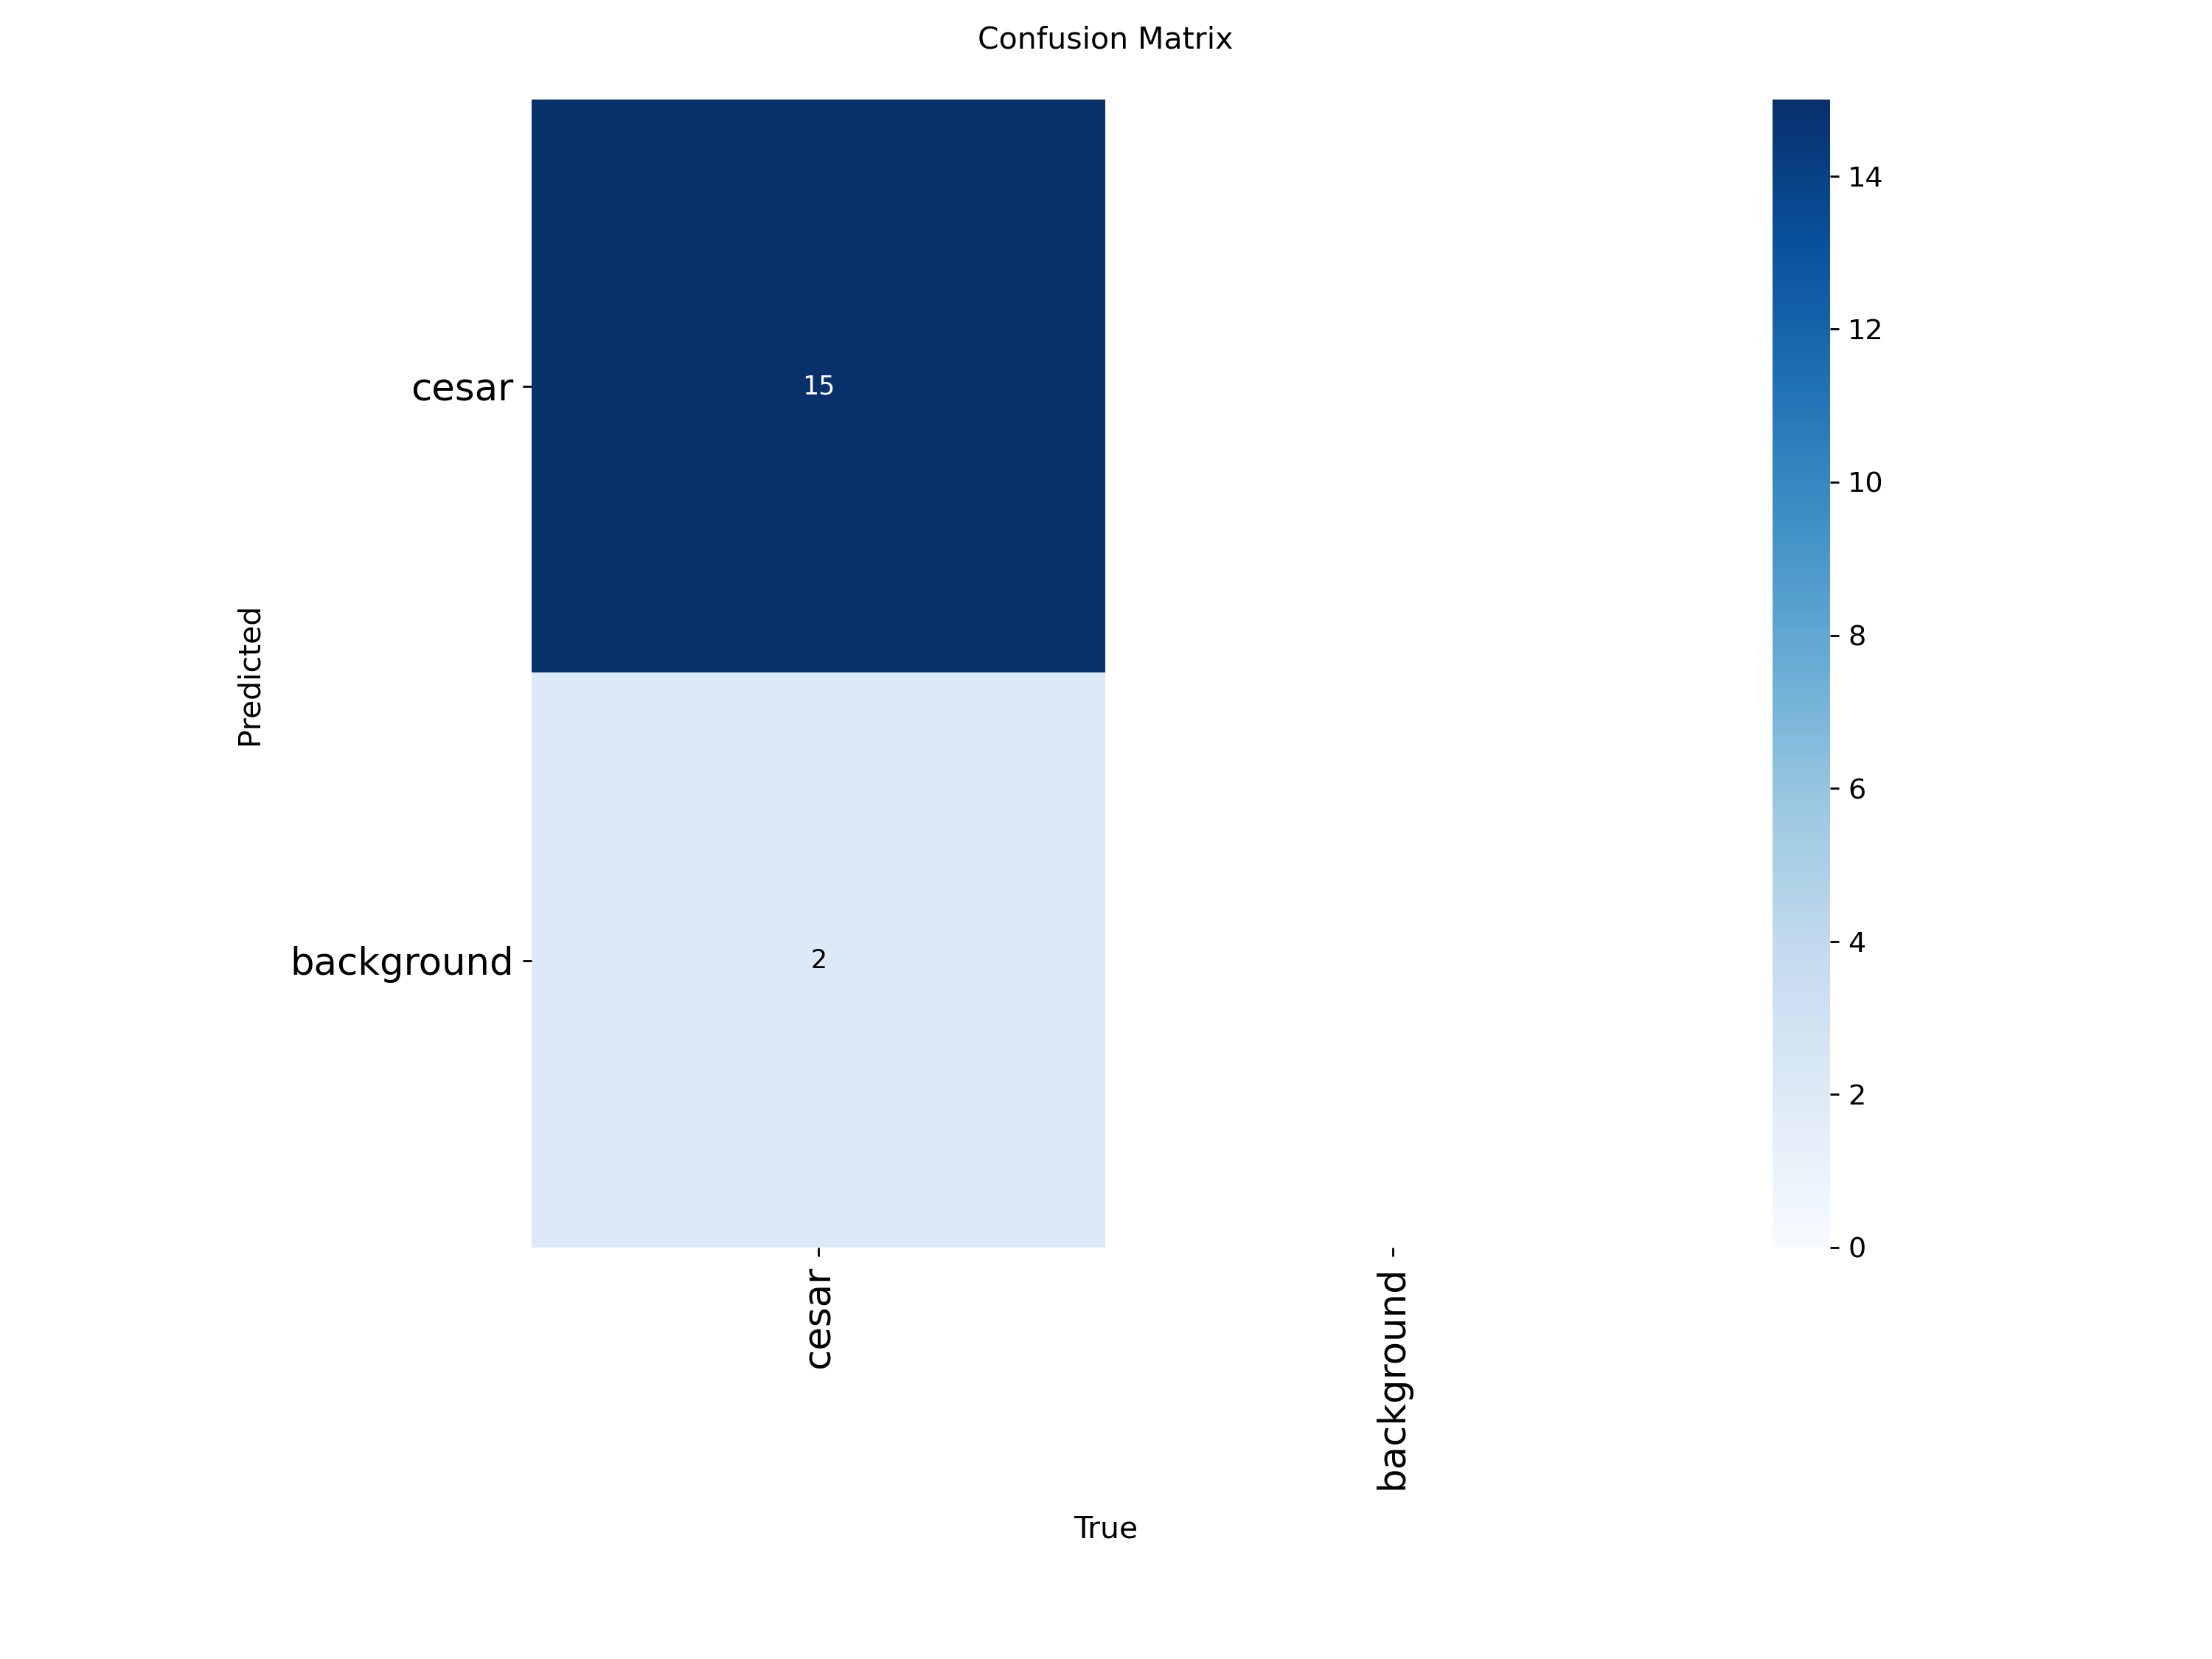

In [26]:
from IPython.display import Image as IPyImage, display

TRAIN_DIR = obtener_train_dir()

confusion_candidates = [
    TRAIN_DIR / "confusion_matrix.png",
    TRAIN_DIR / "confusion_matrix_normalized.png",
]

confusion_png = next((p for p in confusion_candidates if p.exists()), None)

if confusion_png is None:
    print("No se encontró matriz de confusión.")
    print("Archivos .png disponibles en la carpeta de entrenamiento:")
    for p in sorted(TRAIN_DIR.glob("*.png")):
        print(" -", p.name)
else:
    print("Mostrando:", confusion_png)
    display(IPyImage(filename=str(confusion_png), width=650))


## 7. Cargar el mejor modelo entrenado


In [27]:
from ultralytics import YOLO

TRAIN_DIR = obtener_train_dir()
BEST_MODEL_PATH = TRAIN_DIR / "weights" / "best.pt"
LAST_MODEL_PATH = TRAIN_DIR / "weights" / "last.pt"

if BEST_MODEL_PATH.exists():
    MODEL_TRAINED_PATH = BEST_MODEL_PATH
elif LAST_MODEL_PATH.exists():
    MODEL_TRAINED_PATH = LAST_MODEL_PATH
    print("ADVERTENCIA: no existe best.pt. Se usará last.pt.")
else:
    raise FileNotFoundError(
        f"No se encontró best.pt ni last.pt en: {TRAIN_DIR / 'weights'}"
    )

model = YOLO(str(MODEL_TRAINED_PATH))
print("Modelo afinado cargado:", MODEL_TRAINED_PATH)


Modelo afinado cargado: D:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\REENTRENAMIENTO_YOLO\person\runs\person_yolo11n\weights\best.pt


## 8. Predicciones

Como el dataset no trae carpeta `test`, se usará `valid/images` para generar predicciones. Si después agregas `test/images`, el notebook la usará automáticamente.


In [28]:
# Si existe test/images se usa test.
# Si no existe, se usa valid/images.
if (DATASET_DIR / "test" / "images").exists():
    PREDICT_SOURCE = DATASET_DIR / "test" / "images"
else:
    PREDICT_SOURCE = DATASET_DIR / VAL_SPLIT / "images"

if not PREDICT_SOURCE.exists():
    raise FileNotFoundError(f"No se encontró carpeta para predicción: {PREDICT_SOURCE}")

preds = model.predict(
    source=str(PREDICT_SOURCE),
    imgsz=IMG_SIZE,
    conf=0.05,
    iou=0.45,
    save=True,
    save_txt=True,
    save_conf=True,
    project=str(RUNS_DIR),
    name=f"{EXPERIMENT_NAME}_predicciones_conf_005",
    exist_ok=True,
    max_det=10
)

PREDICTIONS_DIR = RUNS_DIR / f"{EXPERIMENT_NAME}_predicciones"

print(f"Predicciones generadas: {len(preds)}")
print("Fuente usada:", PREDICT_SOURCE)
print("Resultados guardados en:", PREDICTIONS_DIR)



image 1/17 D:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\REENTRENAMIENTO_YOLO\person\datasets\dataset_person\valid\images\foto_0001_20260629_002527_jpg.rf.e28ce53fc8ff7b3fa9272300d61fcc68.jpg: 640x640 1 cesar, 179.6ms
image 2/17 D:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\REENTRENAMIENTO_YOLO\person\datasets\dataset_person\valid\images\foto_0006_20260628_074511_jpg.rf.56514e91a56a23c1df3923138a04b3f9.jpg: 640x640 1 cesar, 142.5ms
image 3/17 D:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\REENTRENAMIENTO_YOLO\person\datasets\dataset_person\valid\images\foto_0006_20260629_002537_jpg.rf.b33acd261cfeeda4cfcf37a49ecbd95c.jpg: 640x640 1 cesar, 242.3ms
image 4/17 D:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\REENTRENAMIENTO_YOLO\person\datasets\dataset_person\valid\images\foto_0007_20260628_074513_jpg.rf.ce25ed4e94d29f64ad26fa4678214a80.jpg: 640x640 1 cesar, 186.7ms
image 5/17 D:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\REENTRENAMIENTO_YOLO\person\datasets\dataset_person\valid\images\foto_0009_20260628_074517

## 9. Mostrar una predicción


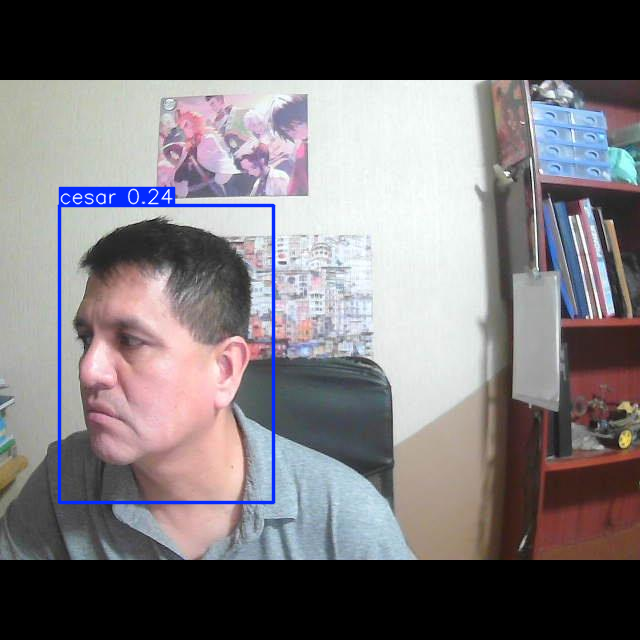

In [30]:
from IPython.display import display
from PIL import Image as PILImage

if len(preds) == 0:
    raise ValueError("No hay predicciones para mostrar.")

idx = min(11, len(preds) - 1)

# Ultralytics devuelve una imagen anotada como arreglo BGR.
# Se convierte a RGB para mostrarla correctamente en el notebook.
imagen_anotada_bgr = preds[idx].plot()
imagen_anotada_rgb = imagen_anotada_bgr[:, :, ::-1]

display(PILImage.fromarray(imagen_anotada_rgb))


## 10. Ubicación final de archivos importantes

Al terminar, revisa estas rutas:

```text
runs/person_yolo11n/weights/best.pt
runs/person_yolo11n/weights/last.pt
runs/person_yolo11n/results.csv
runs/person_yolo11n/results.png
runs/person_yolo11n_predicciones/
```
